Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 189MB/s]


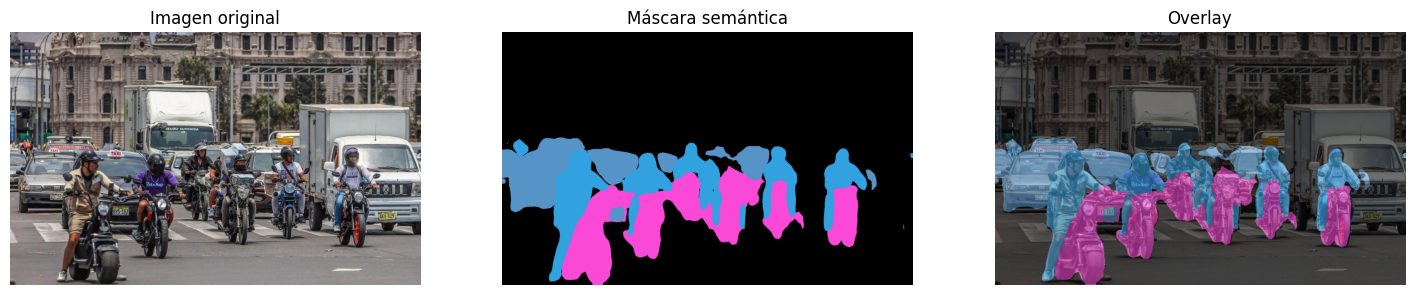

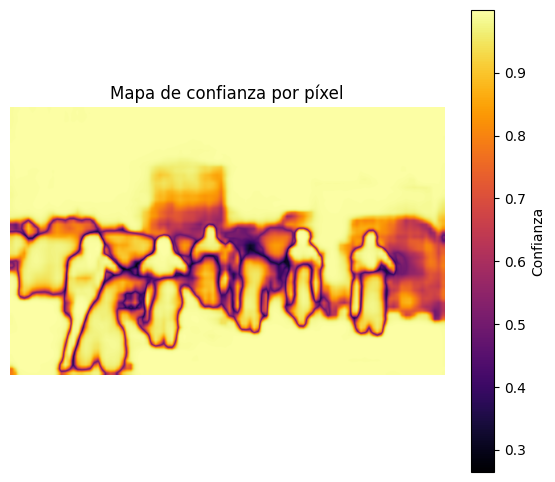

Leyenda de colores (ID -> clase -> RGB):
 0 -> background   -> [0, 0, 0]
 7 -> car          -> [86, 147, 198]
14 -> motorbike    -> [250, 72, 215]
15 -> person       -> [50, 161, 223]


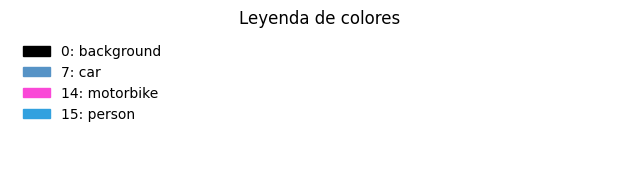

Confianza media por clase (solo clases presentes):
 0 -> background   -> 0.937
 7 -> car          -> 0.784
14 -> motorbike    -> 0.801
15 -> person       -> 0.808
Device: cuda
Resolución imagen: (967, 1569)


In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

IMAGE_PATH = "/content/Motos Lima_ OjoPúblico Aldair Mejía home.jpg"
ALPHA = 0.55

FILTER_IDS = [15, 14]

VOC_CLASSES = {
    0: "background",
    1: "aeroplane",
    2: "bicycle",
    3: "bird",
    4: "boat",
    5: "bottle",
    6: "bus",
    7: "car",
    8: "cat",
    9: "chair",
    10: "cow",
    11: "diningtable",
    12: "dog",
    13: "horse",
    14: "motorbike",
    15: "person",
    16: "pottedplant",
    17: "sheep",
    18: "sofa",
    19: "train",
    20: "tvmonitor"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights).to(device).eval()
preprocess = weights.transforms()

img = Image.open(IMAGE_PATH).convert("RGB")
img_np = np.array(img, dtype=np.uint8)
H, W = img_np.shape[:2]

x = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(x)["out"]
    logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
    probs = F.softmax(logits, dim=1)
    conf_map_t, pred_t = probs.max(dim=1)

pred = pred_t[0].detach().cpu().numpy().astype(np.uint8)
conf_map = conf_map_t[0].detach().cpu().numpy().astype(np.float32)

ids_presentes = np.unique(pred)

if FILTER_IDS is not None and len(FILTER_IDS) > 0:
    mask_keep = np.isin(pred, FILTER_IDS)
    pred_filt = np.zeros_like(pred)
    pred_filt[mask_keep] = pred[mask_keep]
else:
    pred_filt = pred

rng = np.random.default_rng(7)
palette = rng.integers(0, 256, size=(256, 3), dtype=np.uint8)
palette[0] = np.array([0, 0, 0], dtype=np.uint8)

mask_rgb = palette[pred_filt]
overlay = (img_np * (1 - ALPHA) + mask_rgb * ALPHA).astype(np.uint8)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.axis("off")
plt.title("Imagen original")

plt.subplot(1, 3, 2)
plt.imshow(mask_rgb)
plt.axis("off")
plt.title("Máscara semántica")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.axis("off")
plt.title("Overlay")
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(conf_map, cmap="inferno")
plt.colorbar(label="Confianza")
plt.title("Mapa de confianza por píxel")
plt.axis("off")
plt.show()

if FILTER_IDS is not None and len(FILTER_IDS) > 0:
    ids_leyenda = [int(i) for i in ids_presentes if int(i) in set(FILTER_IDS)]
else:
    ids_leyenda = [int(i) for i in ids_presentes]
ids_leyenda = sorted(ids_leyenda)

print("Leyenda de colores (ID -> clase -> RGB):")
handles = []
for i in ids_leyenda:
    name = VOC_CLASSES.get(i, "desconocida")
    rgb = palette[i].tolist()
    print(f"{i:2d} -> {name:12s} -> {rgb}")
    color_norm = (palette[i] / 255.0).tolist()
    handles.append(mpatches.Patch(color=color_norm, label=f"{i}: {name}"))

if len(handles) > 0:
    plt.figure(figsize=(8, max(2, 0.35 * len(handles))))
    plt.axis("off")
    plt.legend(handles=handles, loc="upper left", frameon=False)
    plt.title("Leyenda de colores")
    plt.show()

print("Confianza media por clase (solo clases presentes):")
for cls_id in ids_leyenda:
    mask = (pred == cls_id)
    if mask.any():
        mean_conf = float(conf_map[mask].mean())
        print(f"{cls_id:2d} -> {VOC_CLASSES.get(cls_id, 'desconocida'):12s} -> {mean_conf:.3f}")

print("Device:", device)
print("Resolución imagen:", (H, W))
